In [1]:
import os
import json
import numpy as np
import glob
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import rasterio
from rasterio.plot import show

In [2]:
# path to JSON metadata
geo_meta_path = r'../data/warren/geology.json'

##### create custom color map from GeoTIFF metadata JSON
# NOTE: these are standard colors from Kentucky Geological Survey
with open(geo_meta_path, 'r') as meta:
    geo_meta = json.load(meta)

colors = {'af1': '#636566', 
          'Qal': '#fdf5a4', 
          'Qaf': '#ffa1db', 
          'Qat': '#f9e465', 
          'Qc': '#d6c9a7', 
          'Qca': '#c49d83', 
          'Qr': '#b0acd6'}

cmap = ListedColormap([colors[symbol] for symbol in geo_meta.keys()])

In [16]:
random_patch = '256_50_21983'
paths = glob.glob(r'../data/patches_warren/256_50_21983_*.tif')
paths.sort()

In [17]:
paths

['../data/patches_warren/256_50_21983_aerialb.tif',
 '../data/patches_warren/256_50_21983_aerialg.tif',
 '../data/patches_warren/256_50_21983_aerialnir.tif',
 '../data/patches_warren/256_50_21983_aerialr.tif',
 '../data/patches_warren/256_50_21983_dem.tif',
 '../data/patches_warren/256_50_21983_ep_101x101.tif',
 '../data/patches_warren/256_50_21983_ep_11x11.tif',
 '../data/patches_warren/256_50_21983_ep_201x201.tif',
 '../data/patches_warren/256_50_21983_ep_21x21.tif',
 '../data/patches_warren/256_50_21983_ep_51x51.tif',
 '../data/patches_warren/256_50_21983_ep_5x5.tif',
 '../data/patches_warren/256_50_21983_geology.tif',
 '../data/patches_warren/256_50_21983_logslope.tif',
 '../data/patches_warren/256_50_21983_logslope_10.tif',
 '../data/patches_warren/256_50_21983_logslope_100.tif',
 '../data/patches_warren/256_50_21983_logslope_20.tif',
 '../data/patches_warren/256_50_21983_logslope_200.tif',
 '../data/patches_warren/256_50_21983_logslope_50.tif',
 '../data/patches_warren/256_50_219

['../data/patches_warren/256_50_21983_geology.tif']


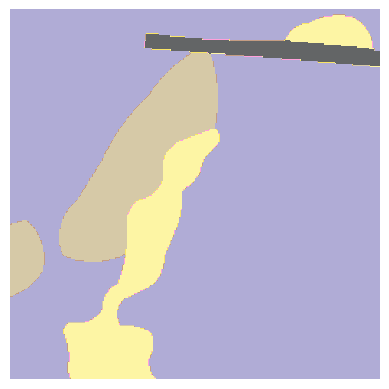

In [35]:
modality = 'geology'

img_paths = []
for path in paths:
    # if ('aerial' in path) and not ('nir' in path):
    #     img_paths.append(path)
    if f"{modality}.tif" in path:
        img_paths.append(path)

print(img_paths)

# img_paths.sort(reverse=True)
# rgb = []
# for img in img_paths:
#     with rasterio.open(img) as src:
#         data = src.read(1)
#         rgb.append(data)
# rgb_img = np.dstack(rgb) / 255


fig, ax = plt.subplots()

# ax.imshow(rgb_img)

for img in img_paths:
    with rasterio.open(img) as src:
        show(src, ax=ax, cmap=cmap, vmin=1, vmax=7)
        # show(src, cmap='PRGn', ax=ax)


ax.set_axis_off()
output_dir = r'/Users/matthew/Library/CloudStorage/OneDrive-UniversityofKentucky/ms_defense/figures/patches'
output_path = f"{output_dir}/{modality}.png"
# output_path = f"{output_dir}/rgb.png"

plt.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()
    